In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [2]:
df = pd.read_csv("grid_search_results_final.csv")
df["is_gru"] = df["unit_type"].apply(lambda x: 1 if x == "GRU" else 0)
df["is_better"] = df["better_than_baseline"].apply(lambda x: 1 if x == True else 0)
df

,config_idx,config_name,n_ae_layers,n_header_layers,unit_type,mask_percent,activation,loss,optimizer,learning_rate,...,epochs_header,test_mae,final_ae_loss,final_header_loss,baseline_lstm_mae,mae_diff,better_than_baseline,status,is_gru,is_better
0,10,ae2_hd2_gru_m20_tanh_adam_lr0.001_bs64_mae,2,2,GRU,0.2,tanh,mae,adam,0.001,...,15,0.001418,0.009552,0.002338,0.004296,-0.002878,True,success,1,1
1,16,ae3_hd1_gru_m20_tanh_adam_lr0.001_bs64_mae,3,1,GRU,0.2,tanh,mae,adam,0.001,...,15,0.001784,0.011107,0.001888,0.004296,-0.002512,True,success,1,1
2,4,ae2_hd1_gru_m20_tanh_adam_lr0.001_bs64_mae,2,1,GRU,0.2,tanh,mae,adam,0.001,...,15,0.002235,0.012360,0.002421,0.004296,-0.002062,True,success,1,1
3,11,ae2_hd2_gru_m50_tanh_adam_lr0.001_bs64_mae,2,2,GRU,0.5,tanh,mae,adam,0.001,...,15,0.002406,0.009775,0.002406,0.004296,-0.001890,True,success,1,1
4,23,ae3_hd2_gru_m50_tanh_adam_lr0.001_bs64_mae,3,2,GRU,0.5,tanh,mae,adam,0.001,...,15,0.003351,0.012334,0.003351,0.004296,-0.000945,True,success,1,1
5,17,ae3_hd1_gru_m50_tanh_adam_lr0.001_bs64_mae,3,1,GRU,0.5,tanh,mae,adam,0.001,...,15,0.003434,0.009565,0.003434,0.004296,-0.000862,True,success,1,1
6,6,ae2_hd1_gru_m80_tanh_adam_lr0.001_bs64_mae,2,1,GRU,0.8,tanh,mae,adam,0.001,...,15,0.004031,0.010954,0.004031,0.004296,-0.000266,True,success,1,1
7,5,ae2_hd1_gru_m50_tanh_adam_lr0.001_bs64_mae,2,1,GRU,0.5,tanh,mae,adam,0.001,...,15,0.004585,0.009732,0.004585,0.004296,0.000289,False,success,1,0
8,22,ae3_hd2_gru_m20_tanh_adam_lr0.001_bs64_mae,3,2,GRU,0.2,tanh,mae,adam,0.001,...,15,0.004939,0.010932,0.004939,0.004296,0.000642,False,success,1,0
9,12,ae2_hd2_gru_m80_tanh_adam_lr0.001_bs64_mae,2,2,GRU,0.8,tanh,mae,adam,0.001,...,15,0.006599,0.010541,0.006599,0.004296,0.002303,False,success,1,0


In [3]:
df.columns

Index(['config_idx', 'config_name', 'n_ae_layers', 'n_header_layers',
       'unit_type', 'mask_percent', 'activation', 'loss', 'optimizer',
       'learning_rate', 'batch_size', 'epochs_ae', 'epochs_header', 'test_mae',
       'final_ae_loss', 'final_header_loss', 'baseline_lstm_mae', 'mae_diff',
       'better_than_baseline', 'status', 'is_gru', 'is_better'],
      dtype='object')

In [4]:
independant_variables = [
    'n_ae_layers', 'n_header_layers', 'is_gru', 'mask_percent'
]

dependant_variables = [
    'test_mae', 'final_ae_loss', 'final_header_loss', 'is_better'
]

In [8]:
df[independant_variables + dependant_variables]

,n_ae_layers,n_header_layers,is_gru,mask_percent,test_mae,final_ae_loss,final_header_loss,is_better
0,2,2,1,0.2,0.001418,0.009552,0.002338,1
1,3,1,1,0.2,0.001784,0.011107,0.001888,1
2,2,1,1,0.2,0.002235,0.012360,0.002421,1
3,2,2,1,0.5,0.002406,0.009775,0.002406,1
4,3,2,1,0.5,0.003351,0.012334,0.003351,1
5,3,1,1,0.5,0.003434,0.009565,0.003434,1
6,2,1,1,0.8,0.004031,0.010954,0.004031,1
7,2,1,1,0.5,0.004585,0.009732,0.004585,0
8,3,2,1,0.2,0.004939,0.010932,0.004939,0
9,2,2,1,0.8,0.006599,0.010541,0.006599,0


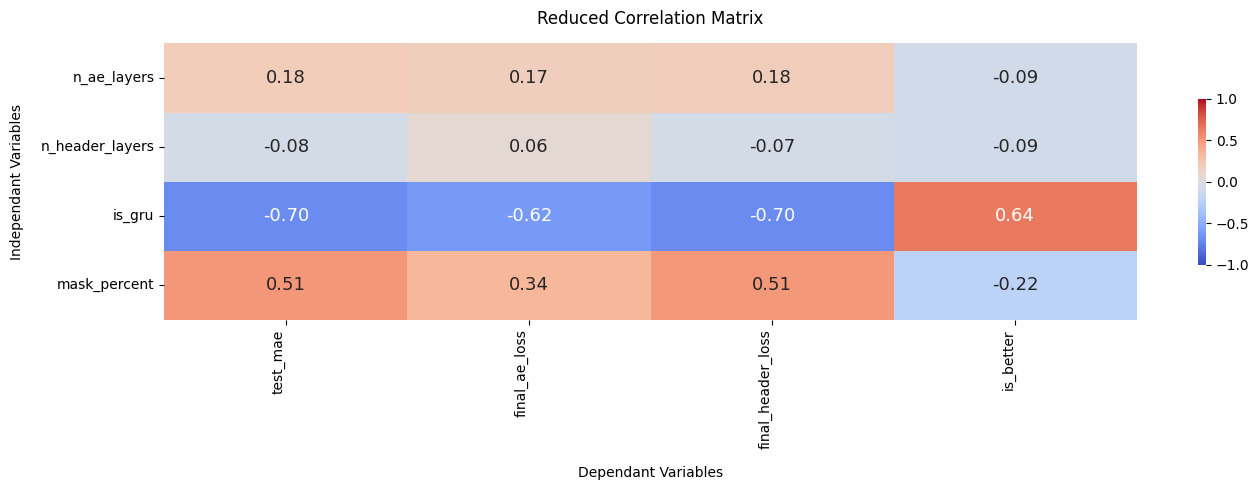

In [5]:
set_bottom = dependant_variables
set_right = independant_variables

A = df[set_right].values
B = df[set_bottom].values

corr = np.corrcoef(A.T, B.T)
corr_mat = corr[:len(set_right), len(set_right):]

corr_df = pd.DataFrame(corr_mat, index=set_right, columns=set_bottom)

# Create figure and axes
fig, ax = plt.subplots(figsize=(14, 5))   # wider figure to fit long x-labels

# Plot heatmap
sns.heatmap(
    corr_df,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1, vmax=1,
    ax=ax,
    cbar_kws={"shrink": 0.6},
    annot_kws={"fontsize": 13}              # reduce annotation font size if crowded
)

# Tweak tick labels so they don't get cut off
ax.set_xlabel("Dependant Variables", labelpad=12)
ax.set_ylabel("Independant Variables", labelpad=12)
ax.set_title("Reduced Correlation Matrix", pad=14)

# Rotate and right-align x tick labels (long names)
plt.xticks(rotation=90, ha="right")
plt.yticks(rotation=0)

# Optionally reduce x tick label font size if still crowded
for tick in ax.get_xticklabels():
    tick.set_fontsize(10)

# Tight layout and save without clipping
plt.tight_layout()
plt.savefig("reduced_corr_matrix.png", dpi=300, bbox_inches="tight")
plt.show()

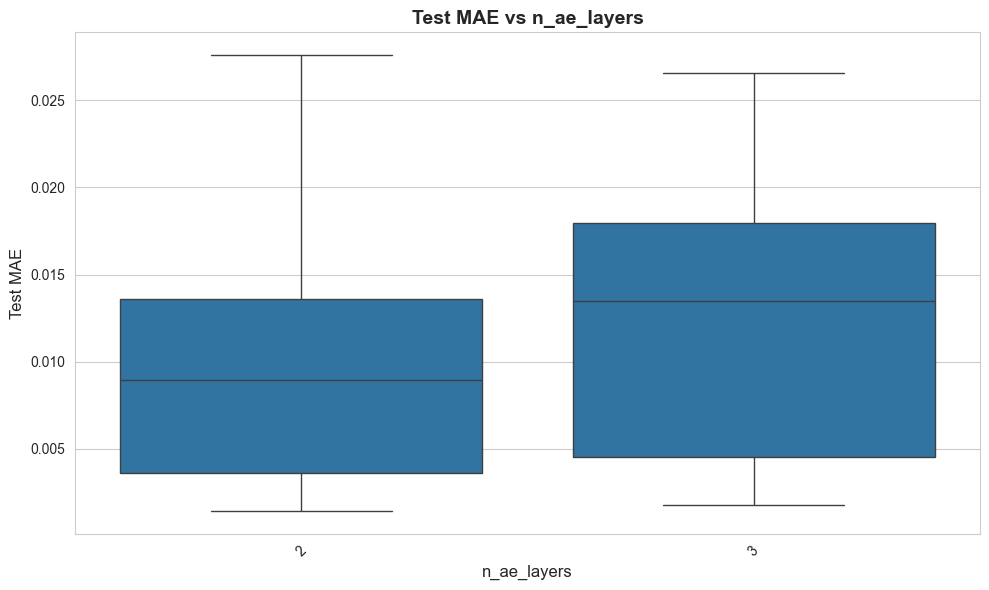

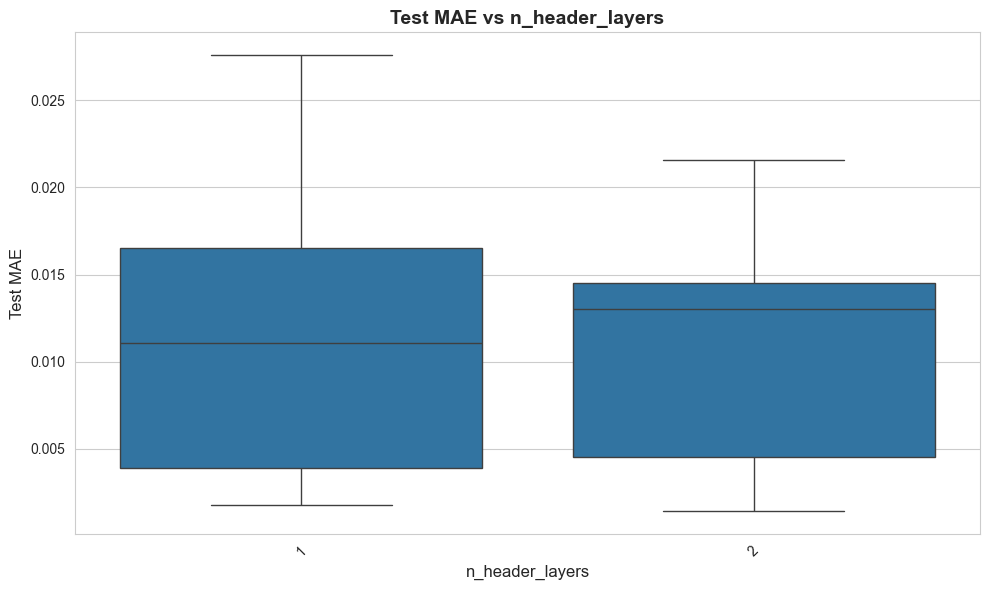

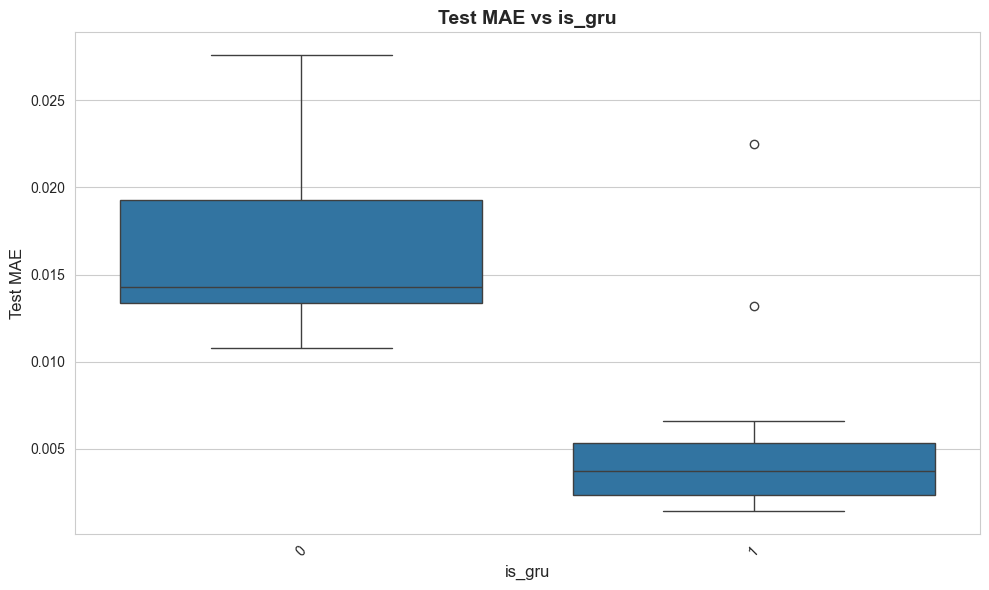

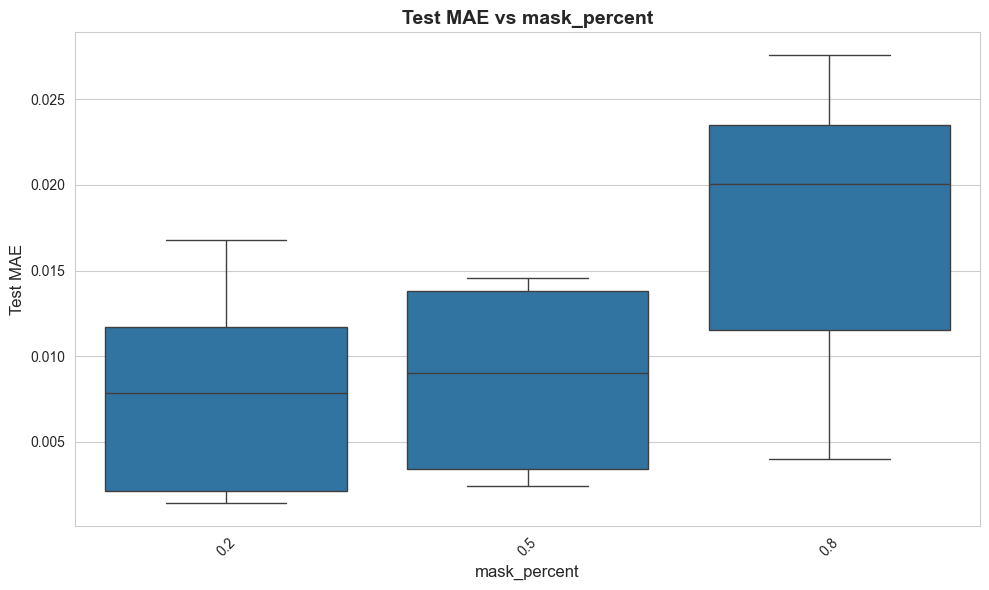

In [6]:
sns.set_style("whitegrid")

for var in independant_variables:
    plt.figure(figsize=(10, 6))
    
    n_unique = df[var].nunique()
    
    if n_unique <= 10:  # Categorical or few unique values
        sns.boxplot(data=df, x=var, y='test_mae')
    else:  # Continuous variable
        sns.scatterplot(data=df, x=var, y='test_mae', alpha=0.6)
        # Add a trend line
        sns.regplot(data=df, x=var, y='test_mae', scatter=False, color='red')
    
    plt.title(f'Test MAE vs {var}', fontsize=14, fontweight='bold')
    plt.xlabel(var, fontsize=12)
    plt.ylabel('Test MAE', fontsize=12)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()